In [1]:
import pandas as pd
import matplotlib.pyplot as plt

import re

In [2]:
def load_data():
    return pd.read_csv('Global_Smartwatch_Marketplace.csv')

df = load_data()

df = df[df['brand']=='Apple']

In [3]:
# ---------- Cleaning the Data ---------------


# Drop two extreme values
#df = df.drop(df.index[[2524, 1662]]) 

# Standardize conditition column
condition_map= {
    'Nuevo':'New',
    'New other':'New',
    'Caja abierta':'Open box',
    'Usado':'Used',
    '--':'Unknown'
}

df['condition_std'] = df['condition'].map(condition_map).fillna(df['condition'])


# Standardize Country column

country_map = {
    'Corea del Sur':'South Korea',
    'Reino Unido':'United Kingdom',
    'Estados Unidos':'United States',
    
}

df['country_clean'] = df['Country'].map(country_map).fillna(df['Country'])

# ------------- Extract model and model_number from Title------------


In [4]:


BRAND_CONFIG = {
    "garmin": {
    "families": ["approach", "fenix", "venu", 
                 "forerunner", "instinct", "tactix", 
                 "descent", "epix", "quarix", "lily",
                "vivoactive", "tacx", "enduro"],
    "model_pattern": [
        r'gen\s?(\d+)',              # Gen 2
        r'\b(\d+[xs])\b',            # 7x, 7s
        r'\b([a-z]\d+)\b',           # S32
        r'(mk\s?\d+i?)',             # Mk2
        r'(mk\s?[ivx]+i?)',          # MkII
        r'(flux\s?[a-z])'
    ],
    "luxury_keywords": ["pro", "sapphire", "titanium", "solar"]
},
    
    "apple": {
    "families": ["series", "ultra", "se", 'hermes'],
    "model_pattern": [
        r'series\s?(\d+)',     # Series 10 → 10
        r'\bs(\d{1,2})\b',     # S8 → 8
        r'ultra\s?(\d*)',      # Ultra 2 → 2 (or empty)
        r'se\s?(\d*)',          # SE 2 → 2
        r'(\d+)'
    ],
    "luxury_keywords": ["ultra", "titanium"]
},
    
    "samsung": {
        "families": ["watch"],
        "model_pattern": [
            r'(ultra)',
            r'(\d+)',
            r'([a-z]\s?\d+)'
        ],
        "luxury_keywords": ["pro", "classic"]
},
    
    "xiaomi": {
        "families": ["watch"],
        "model_pattern": [
            r'([a-z]\d+)',
            r'([a-z]\s?\d+)',
            r'(\d+)'
        ],
        "luxury_keywords": ["pro", "classic"]
    }
}


In [5]:
def extract_features(row):
    title = str(row['title']).lower()
    brand = str(row['brand']).lower()
    
    # --- skip unknown brands ---
    if brand not in BRAND_CONFIG:
        return None, None, 0
    
    config = BRAND_CONFIG[brand]
    
    # --- FAMILY ---
    family = None
    for fam in config["families"]:
        if fam in title:
            family = fam
            break
    
    # --- MODEL NUMBER ---
    model = None
    
  
    if brand == "apple":
    
        # --- SPECIAL CASE: HERMES ---
        if "hermes" in title:
            family = "hermes"
            model = 'hermes'

        if family:
            for pattern in config["model_pattern"]:
                match = re.search(pattern, title)
                if match:
                    model = match.group(1)
                    break
    

    elif brand == "garmin":
        if family:
            start = title.find(family)
            sub = title[start:start + 40]

            model = None  # default

            # --- PRIORITY: family + number (e.g. "fenix 8")
            match = re.search(rf'{family}\s?(\d+)', sub)
            if match:
                candidate = match.group(1)

                # reject if it's part of measurement like "47mm"
                if not re.search(rf'{candidate}\s?(mm|cm|in|inch|")', sub):
                    model = candidate

            # --- FALLBACK: other patterns
            if model is None:
                for pattern in config["model_pattern"]:
                    match = re.search(pattern, sub)
                    if match:
                        candidate = match.group(1)

                        # reject measurement artifacts
                        if re.search(rf'{candidate}\s?(mm|cm|in|inch|")', sub):
                            continue

                        model = candidate
                        break
    

    elif brand == "samsung":
        for pattern in config["model_pattern"]:
            match = re.search(pattern, title)
            if match:
                # always use captured group (number only)
                model = match.group(1)
                break
    
    if brand == "xiaomi":
        for pattern in config["model_pattern"]:
            full_pattern = rf'{family}[\s\-]*{pattern}'
            match = re.search(full_pattern, title)
            if match:
                # always use captured group (number only)
                model = match.group(1)
                break
            
    
    # --- NORMALIZE MODEL ---
    if model:
        model = model.replace(" ", "").upper()
        
        # optional: normalize roman numerals (Garmin MKII → MK2)
        roman_map = {
            "III": "3",
            "II": "2",
            "IV": "4",
            "I": "1"
        }
        for r, d in roman_map.items():
            model = model.replace(r, d)
    
    # --- LUXURY FLAG ---
    luxury_flag = int(any(word in title for word in config["luxury_keywords"]))
    
    return family, model, luxury_flag


In [6]:
df[['family', 'model_number', 'luxury_flag']] = df.apply(
    extract_features,
    axis=1,
    result_type='expand'
)

df['family'] = df['family'].fillna('Unknown')
df['model_number'] = df['model_number'].fillna('Unknown')
df['luxury_flag'] = df['luxury_flag'].fillna(0)

# ---------------PHASE II: Encoding the categorical columns---------------------

In [7]:
import numpy as np

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import OneHotEncoder

In [8]:
df.columns

Index(['brand', 'condition', 'Case_Size_mm', 'Country', 'price', 'Seller_ID',
       'Is_Worldwide_Shipping', 'title', 'condition_std', 'country_clean',
       'family', 'model_number', 'luxury_flag'],
      dtype='object')

In [9]:
df['model_number'] = pd.to_numeric(df['model_number'], errors='coerce')
df = df.dropna(subset = ['model_number'])

df = df[(df['model_number']<=12) & (df['model_number']>0)]

In [10]:
df['model_number'].value_counts()

2.0     593
3.0     424
10.0    199
11.0    180
9.0     129
7.0     128
6.0     119
8.0     113
5.0      51
4.0      45
1.0      30
Name: model_number, dtype: int64

In [11]:
# Make X and y train_test

X = df.drop(columns=['price', 'condition', 'Country', 'title'])
y = (df['price'])                                            # Log transforming price

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
# Replacing NaN values in Case_Size_mm with median from training set

median_case_size = X_train['Case_Size_mm'].median()

X_train['Case_Size_mm'] = X_train['Case_Size_mm'].fillna(median_case_size)
X_test['Case_Size_mm'] = X_test['Case_Size_mm'].fillna(median_case_size)

In [13]:
# Preparing to Target Encode categorical columns using Out Of Fold encoding

def oof_target_encode(train_series, y, test_series, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    oof_train = pd.Series(index=train_series.index, dtype=float)
    test_encoded = np.zeros(len(test_series))
    
    global_mean = y.mean()
    
    for train_idx, val_idx in kf.split(train_series):
        X_tr, X_val = train_series.iloc[train_idx], train_series.iloc[val_idx]
        y_tr = y.iloc[train_idx]
        
        means = y_tr.groupby(X_tr).mean()
        
        # map validation fold
        oof_train.iloc[val_idx] = X_val.map(means)
    
    # fill unseen with global mean
    oof_train.fillna(global_mean, inplace=True)
    
    # test encoding (use FULL train)
    full_means = y.groupby(train_series).mean()
    test_encoded = test_series.map(full_means).fillna(global_mean)
    
    return oof_train, test_encoded

In [14]:
# Target encoding columns
target_cols = ['Seller_ID', 'country_clean']

for col in target_cols:
    X_train[col + '_te'], X_test[col + '_te'] = oof_target_encode(
        X_train[col], y_train, X_test[col]
    )

# drop original columns
X_train.drop(columns=target_cols, inplace=True)
X_test.drop(columns=target_cols, inplace=True)

In [15]:
# One-hot encode the rest of the categorical columns

ohe_cols = ['brand', 'condition_std']

encoder = OneHotEncoder(handle_unknown='ignore', sparse=False)

# fit only on train
X_train_ohe = encoder.fit_transform(X_train[ohe_cols])
X_test_ohe = encoder.transform(X_test[ohe_cols])

# convert to DataFrame
ohe_feature_names = encoder.get_feature_names_out(ohe_cols)

X_train_ohe = pd.DataFrame(X_train_ohe, columns=ohe_feature_names, index=X_train.index)
X_test_ohe = pd.DataFrame(X_test_ohe, columns=ohe_feature_names, index=X_test.index)

# drop original columns
X_train.drop(columns=ohe_cols, inplace=True)
X_test.drop(columns=ohe_cols, inplace=True)

X_train.drop(columns=['family'], inplace=True)
X_test.drop(columns=['family'], inplace=True)



X_train['Seller_ID_te'] = np.log1p(X_train['Seller_ID_te'])
X_test['Seller_ID_te'] = np.log1p(X_test['Seller_ID_te'])


# combine
X_train = pd.concat([X_train, X_train_ohe], axis=1)
X_test = pd.concat([X_test, X_test_ohe], axis=1)

In [16]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

In [17]:
tree = DecisionTreeRegressor().fit(X_train, y_train)
y_tree_pred = tree.predict(X_test)

In [18]:
X_train

,Case_Size_mm,Is_Worldwide_Shipping,model_number,luxury_flag,Seller_ID_te,country_clean_te,brand_Apple,condition_std_Excellent - Refurbished,condition_std_For parts or not working,condition_std_Good - Refurbished,condition_std_New,condition_std_Open box,condition_std_Used,condition_std_Very Good - Refurbished
517,46.0,0,11.0,1.0,6.371355,631.706734,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1152,49.0,0,2.0,1.0,6.406963,634.069611,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3537,45.0,0,8.0,0.0,6.406963,631.706734,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
478,40.0,0,6.0,0.0,6.406963,631.706734,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1493,44.0,1,6.0,0.0,6.746691,631.422545,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2006,46.0,0,3.0,1.0,6.345180,631.706734,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2322,45.0,0,9.0,0.0,6.406963,634.069611,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1555,49.0,0,2.0,1.0,6.406963,631.422545,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2613,42.0,0,10.0,0.0,6.406963,631.706734,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [19]:
clf = GradientBoostingRegressor().fit(X_train, y_train)
y_pred = (clf.predict(X_test))

In [20]:
y_true = (y_test)

r2_score(y_true, y_pred)

0.2539211862303221

In [21]:
X_train_no_te = X_train.drop(columns = ['Seller_ID_te', 'country_clean_te'])
X_test_no_te = X_test.drop(columns=['Seller_ID_te', 'country_clean_te'])

clf_no_te = GradientBoostingRegressor().fit(X_train_no_te, y_train)


clf_no_te.score(X_test_no_te, y_test)

0.11281427426792467

In [22]:
len(df[df['brand']=='Apple'])

2011

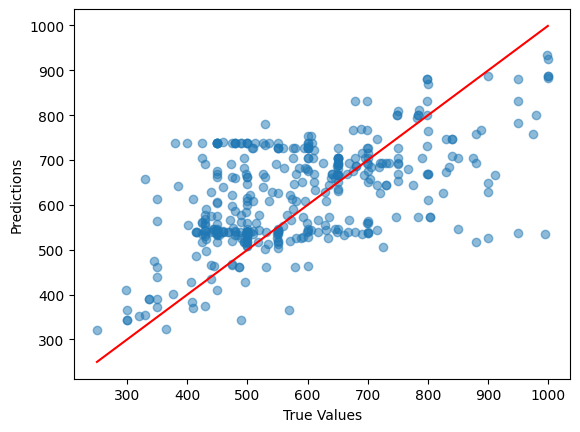

In [23]:
plt.scatter(y_true, y_pred, alpha=0.5)
plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], color='red') # Identity line
plt.xlabel('True Values')
plt.ylabel('Predictions')
plt.show()

In [24]:
np.std(y_pred)

112.96043558923846